In [1]:
from __future__ import annotations

# -----------------------------------------------------------------------------
# EDIT THESE VALUES FOR YOUR CLUSTER ALLOCATION
# -----------------------------------------------------------------------------
# USER_NAME is your Linux username / /home folder name.
# VISIBLE_GPUS are the physical GPU IDs assigned to you, comma-separated.
# After CUDA masking, the first listed physical GPU becomes cuda:0 in this notebook.
# SGLANG_PHYSICAL_GPU is the physical GPU reserved for the SGLang AV server.
USER_NAME = "kaylee"
VISIBLE_GPUS = "0,1"
SGLANG_PHYSICAL_GPU = "1"
LOCAL_DEVICE = "cuda:0"
# -----------------------------------------------------------------------------

# Run this notebook from a fresh kernel. CUDA_VISIBLE_DEVICES must be set before
# importing torch, so this setup cell intentionally defines paths/GPUs first.
import os
from pathlib import Path

## Experiment Overview

All experiments share one AV server and use the same target tokenizer/model state where possible. The notebook deliberately unloads the 27B target before loading the AR, then reloads the target for introspection, so the full target and AR do not coexist on the notebook GPU.

Results are printed and displayed near the cells that produce them. Round-trip and paraphrasing summaries are also written beneath the configurable experiment output root; introspection and zero-vector results remain notebook-only.

In [2]:
HOME = Path("/home") / USER_NAME
NLA_REPO = Path(os.environ.get("NLA_REPO", HOME / "natural_language_autoencoders"))
SGLANG_REPO = Path(os.environ.get("SGLANG_REPO", HOME / "sglang"))
VENV_PYTHON = Path(os.environ.get("NLA_VENV_PYTHON", NLA_REPO / ".venv/bin/python"))
HF_CACHE = Path(os.environ.get("HF_HOME", HOME / ".cache/huggingface"))
ROOT = Path(os.environ.get("NLA_EXPERIMENT_ROOT", HOME / "experiments/nla_experiments"))
LIBNUMA_DIR = Path(
    os.environ.get(
        "NLA_LIBNUMA_DIR", NLA_REPO / "vendor/libnuma/usr/lib/x86_64-linux-gnu"
    )
)
PYTHON_INCLUDE_DIRS = [
    Path(
        os.environ.get(
            "NLA_PYTHON_INCLUDE",
            NLA_REPO / "vendor/python3.10-dev/usr/include/python3.10",
        )
    ),
    Path(
        os.environ.get(
            "NLA_PYTHON_MULTIARCH_INCLUDE",
            NLA_REPO / "vendor/python3.10-dev/usr/include",
        )
    ),
]
ROOT.mkdir(parents=True, exist_ok=True)


os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = VISIBLE_GPUS
os.environ["HF_HOME"] = str(HF_CACHE)
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
if LIBNUMA_DIR.exists():
    os.environ["LD_LIBRARY_PATH"] = (
        f"{LIBNUMA_DIR}:{os.environ.get('LD_LIBRARY_PATH', '')}"
    )
_existing_cpath = os.environ.get("CPATH", "")
_include_paths = [str(path) for path in PYTHON_INCLUDE_DIRS if path.exists()]
if _include_paths:
    os.environ["CPATH"] = ":".join([*_include_paths, _existing_cpath])

import gc
import math
import random
import re
import subprocess
import time
from contextlib import contextmanager
from typing import Any

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from huggingface_hub import snapshot_download
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed
import math
from nla.schema import normalize_activation

# Local NLA inference helpers from the released repo.
import sys

sys.path.insert(0, str(NLA_REPO))
from nla_inference import NLAClient, NLACritic

TARGET_MODEL = "google/gemma-3-27b-it"
ACTOR_REPO_ID = os.environ.get("NLA_ACTOR_DIR", "kitft/nla-gemma3-27b-L41-av")
AR_REPO_ID = os.environ.get("NLA_AR_DIR", "kitft/nla-gemma3-27b-L41-ar")
SGLANG_URL = os.environ.get("SGLANG_URL", "http://127.0.0.1:30000")
SGLANG_LOG = Path.home() / "logs" / "sglang_av_server.log"
SGLANG_LOG.parent.mkdir(parents=True, exist_ok=True)
LAYER_INDEX = 41
DEVICE = LOCAL_DEVICE
SEED = 1234
N_EXAMPLES = 200


def resolve_checkpoint(path_or_repo_id: str) -> str:
    """Return a local checkpoint path with nla_meta.yaml available."""
    candidate = Path(path_or_repo_id).expanduser()
    if candidate.exists():
        assert (
            candidate / "nla_meta.yaml"
        ).exists(), f"Missing nla_meta.yaml in {candidate}"
        return str(candidate)
    local_path = Path(snapshot_download(repo_id=path_or_repo_id))
    assert (
        local_path / "nla_meta.yaml"
    ).exists(), f"Missing nla_meta.yaml in downloaded snapshot {local_path}"
    return str(local_path)


ACTOR_DIR = resolve_checkpoint(ACTOR_REPO_ID)
AR_DIR = resolve_checkpoint(AR_REPO_ID)

assert NLA_REPO.exists(), f"Missing NLA repo: {NLA_REPO}"
assert SGLANG_REPO.exists(), f"Missing patched SGLang checkout: {SGLANG_REPO}"
assert VENV_PYTHON.exists(), f"Missing NLA venv Python: {VENV_PYTHON}"

print("home:", HOME)
print("NLA repo:", NLA_REPO)
print("SGLang checkout:", SGLANG_REPO)
print("HF cache:", HF_CACHE)
print("experiment output:", ROOT)
print("vendored libnuma:", LIBNUMA_DIR if LIBNUMA_DIR.exists() else "not found")
print("vendored Python includes:", [p for p in PYTHON_INCLUDE_DIRS if p.exists()])
print("visible physical GPUs:", VISIBLE_GPUS)
print("SGLang physical GPU:", SGLANG_PHYSICAL_GPU)
print("notebook device:", DEVICE)
print("actor checkpoint:", ACTOR_DIR)
print("AR checkpoint:", AR_DIR)
print(torch.__version__, torch.cuda.is_available())
if torch.cuda.is_available():
    print("visible cuda devices:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"cuda:{i}", torch.cuda.get_device_name(i))

UV_PYTHON_INCLUDE = "/home/kaylee/.local/share/uv/python/cpython-3.10.20-linux-x86_64-gnu/include/python3.10"
assert os.path.exists(os.path.join(UV_PYTHON_INCLUDE, "Python.h")), "Python.h not found at that path"

os.environ["CPATH"] = f"{UV_PYTHON_INCLUDE}:{os.environ.get('CPATH', '')}"
print("CPATH now:", os.environ["CPATH"])

REAL_LIBNUMA_DIR = "/home/kaylee/.local/lib"
assert os.path.exists(os.path.join(REAL_LIBNUMA_DIR, "libnuma.so.1")), "libnuma.so.1 not found there"

os.environ["LD_LIBRARY_PATH"] = f"{REAL_LIBNUMA_DIR}:{os.environ.get('LD_LIBRARY_PATH', '')}"
print("LD_LIBRARY_PATH now:", os.environ["LD_LIBRARY_PATH"])

# !rm -rf ~/.triton/cache

print("LD_LIBRARY_PATH:", os.environ.get("LD_LIBRARY_PATH"))
print("CPATH:", os.environ.get("CPATH"))

Fetching 38 files:   0%|          | 0/38 [00:00<?, ?it/s]

Fetching 22 files:   0%|          | 0/22 [00:00<?, ?it/s]

home: /home/kaylee
NLA repo: /home/kaylee/natural_language_autoencoders
SGLang checkout: /home/kaylee/sglang
HF cache: /home/kaylee/.cache/huggingface
experiment output: /home/kaylee/experiments/nla_experiments
vendored libnuma: not found
vendored Python includes: []
visible physical GPUs: 0,1
SGLang physical GPU: 1
notebook device: cuda:0
actor checkpoint: /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-av/snapshots/4e721238131ffb8348cff260fe81b8b34a270a0d
AR checkpoint: /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-ar/snapshots/aa2f29723c4807caf5f665dac004998df71b7cfb
2.9.1+cu128 True
visible cuda devices: 2
cuda:0 NVIDIA A100-SXM4-80GB
cuda:1 NVIDIA A100-SXM4-80GB
CPATH now: /home/kaylee/.local/share/uv/python/cpython-3.10.20-linux-x86_64-gnu/include/python3.10:
LD_LIBRARY_PATH now: /home/kaylee/.local/lib:/home/kaylee/.local/lib:
LD_LIBRARY_PATH: /home/kaylee/.local/lib:/home/kaylee/.local/lib:
CPATH: /home/kaylee/.local/share/uv/python

## Start The AV Server

The AV uses SGLang because the checkpoint expects `input_embeds` injection. This notebook launches the patched editable SGLang checkout through the NLA `.venv`, pinned to the physical GPU chosen in the setup cell.



In [3]:
def launch_sglang_actor() -> subprocess.Popen:
    env = os.environ.copy()
    env["HF_HOME"] = str(HF_CACHE)
    env["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
    env["CUDA_VISIBLE_DEVICES"] = SGLANG_PHYSICAL_GPU
    env["SGLANG_MIN_NEW_TOKEN_RATIO_FACTOR"] = "1"
    env["PYTHONPATH"] = f"{NLA_REPO}:{env.get('PYTHONPATH', '')}"
    if LIBNUMA_DIR.exists():
        env["LD_LIBRARY_PATH"] = f"{LIBNUMA_DIR}:{env.get('LD_LIBRARY_PATH', '')}"
    include_paths = [str(path) for path in PYTHON_INCLUDE_DIRS if path.exists()]
    if include_paths:
        env["CPATH"] = ":".join([*include_paths, env.get("CPATH", "")])

    cmd = [
        str(VENV_PYTHON),
        "-m",
        "sglang.launch_server",
        "--model-path",
        ACTOR_DIR,
        "--port",
        "30000",
        "--host",
        "127.0.0.1",
        "--disable-radix-cache",
        "--mem-fraction-static",
        "0.80",
        "--context-length",
        "512",
        "--attention-backend",
        "triton",
        "--disable-cuda-graph",
        "--trust-remote-code",
        "--log-level",
        "warning",
    ]
    print("Launching SGLang on physical GPU", SGLANG_PHYSICAL_GPU)
    print(" ".join(cmd))
    print("SGLang server logs ->", SGLANG_LOG)
    log_f = open(SGLANG_LOG, "ab", buffering=0)
    return subprocess.Popen(
        cmd, env=env, cwd=str(NLA_REPO), stdout=log_f, stderr=subprocess.STDOUT
    )



def sglang_is_healthy() -> bool:
    import urllib.request

    try:
        urllib.request.urlopen(SGLANG_URL + "/health", timeout=2).read()
        return True
    except Exception:
        return False


def wait_for_sglang(timeout_s: int = 300) -> None:
    deadline = time.time() + timeout_s
    last_error = None
    while time.time() < deadline:
        if sglang_is_healthy():
            print("SGLang is healthy")
            return
        try:
            import urllib.request

            urllib.request.urlopen(SGLANG_URL + "/health", timeout=2).read()
        except Exception as exc:
            last_error = exc
        time.sleep(2)
    raise TimeoutError(f"SGLang did not become healthy: {last_error!r}")


sglang_proc = None
if sglang_is_healthy():
    print("SGLang is already healthy at", SGLANG_URL)
else:
    sglang_proc = launch_sglang_actor()
    wait_for_sglang()

Launching SGLang on physical GPU 1
/home/kaylee/natural_language_autoencoders/.venv/bin/python -m sglang.launch_server --model-path /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-av/snapshots/4e721238131ffb8348cff260fe81b8b34a270a0d --port 30000 --host 127.0.0.1 --disable-radix-cache --mem-fraction-static 0.80 --context-length 512 --attention-backend triton --disable-cuda-graph --trust-remote-code --log-level warning
SGLang server logs -> /home/kaylee/logs/sglang_av_server.log


SGLang is healthy


In [4]:
print(sglang_is_healthy())

True


## Experiment Setup

In [5]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

tokenizer = AutoTokenizer.from_pretrained(TARGET_MODEL, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    TARGET_MODEL, torch_dtype=torch.bfloat16, device_map={"": DEVICE},
    trust_remote_code=True, attn_implementation="eager",
).eval()
del model.model.vision_tower
gc.collect()
torch.cuda.empty_cache()
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/12 [00:00<?, ?it/s]

In [6]:
print("model" in globals())
if "model" in globals():
    print(model.device if hasattr(model, "device") else next(model.parameters()).device)

True
cuda:0


In [7]:
client = NLAClient(ACTOR_DIR, sglang_url=SGLANG_URL)
critic = NLACritic(AR_DIR, device="cpu", dtype=torch.float32)
print("Target and AV client ready")


[NLAClient] 4e721238131ffb8348cff260fe81b8b34a270a0d: d_model=5376 inj_scale=60000.0 embed_scale=73.32 inj_char='㈜'(id=246566)


Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Some weights of Gemma3ForCausalLM were not initialized from the model checkpoint at /home/kaylee/.cache/huggingface/hub/models--kitft--nla-gemma3-27b-L41-ar/snapshots/aa2f29723c4807caf5f665dac004998df71b7cfb and are newly initialized: ['model.norm.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


[NLACritic] 42 layers  d_model=5376  mse_scale=73.32
Target and AV client ready


The reconstruction error is
$$
\mathcal{L} = \mathbb{E}_{h_l \sim \mathcal{H}} \mathbb{E}_{z \sim AV(\cdot | h_l)} [||h_l - AR(z)||_2^2]
$$
where $\mathcal{H}$ is the distribution produced by extracting layer $l$ activations from $M$ on a corpus of text. 

The FVE is
$$
1 - \frac{L}{ \mathbb{E}_{h_l \sim \mathcal{H}} ||h_l - \bar{h_l}||^2_2}
$$

In [8]:
def av(h: torch.Tensor) -> str:
    v = h.detach().float().cpu().numpy()
    return client.generate(v, temperature=0.0, max_new_tokens=384, extract_explanation=True)


PARAPHRASE_PROMPT = (
    "Please paraphrase the text provided below, preserving its exact meaning "
    "but expressing it in substantially different words and sentence structure "
    "than the original. Do not simply swap individual words for synonyms -- "
    "restructure the sentence(s) genuinely.\n\n"
    "<text>\n{text}\n</text>\n\n"
    "Include your final paraphrased text in <transformed_text> tags."
)

def ar(text: str) -> torch.Tensor:
    return critic.reconstruct(text)  # raw, unnormalized -- matches h's scale


# --- Patch hook: replace the residual stream at the last prompt token ---
class LastTokenPatcher:
    def __init__(self, patch_vec=None):
        self.patch_vec = patch_vec
        self.captured = None
        self._done = False  # only patch once

    def __call__(self, module, inputs, output):
        hidden = output[0] if isinstance(output, tuple) else output
        # Only act on the initial multi-token prefill pass, not each
        # single-token decode step that follows.
        if hidden.shape[1] > 1 and not self._done:
            self.captured = hidden[0, -1, :].detach().clone()
            if self.patch_vec is not None:
                hidden = hidden.clone()
                hidden[0, -1, :] = self.patch_vec.to(hidden.dtype).to(hidden.device)
            self._done = True
            return (hidden,) + output[1:] if isinstance(output, tuple) else hidden
        return output


def mse_cos_from_reconstruction(h_hat: torch.Tensor, h_orig: torch.Tensor, mse_scale: float):
    """Per-example, norm-matched metrics (for reporting alongside FVE, not used *in* FVE)."""
    pred = h_hat.float()
    gold = h_orig.float().cpu()
    pred_n = pred / pred.norm().clamp_min(1e-12) * mse_scale
    gold_n = gold / gold.norm().clamp_min(1e-12) * mse_scale
    mse = ((pred_n - gold_n) ** 2).mean().item()
    cos = (pred_n @ gold_n / (pred_n.norm() * gold_n.norm())).item()
    return mse, cos


def raw_sq_error(h_hat: torch.Tensor, h_orig: torch.Tensor) -> float:
    """||h_orig - h_hat||^2 on raw, unnormalized activations -- this is what
    the paper's L and FVE are defined over, so it must NOT be norm-rescaled
    the way mse_cos_from_reconstruction's inputs are."""
    assert h_hat.dim() == 1 and h_orig.dim() == 1, f"{h_hat.shape=} {h_orig.shape=}"
    return ((h_orig.float().cpu() - h_hat.float().cpu()) ** 2).sum().item()


def fve(sq_errors: list, h_orig_list: list) -> float:
    """FVE = 1 - E[||h - AR(z)||^2] / E[||h - h_bar||^2], both expectations
    taken over the same sample. h_bar is estimated as the sample mean of
    h_orig_list -- this must be computed over the full run, not per-example."""
    h_stack = torch.stack([h.float().cpu() for h in h_orig_list])  # [N, d]
    h_bar = h_stack.mean(dim=0)
    variance = ((h_stack - h_bar) ** 2).sum(dim=1).mean().item()
    L = sum(sq_errors) / len(sq_errors)
    return 1 - L / variance


def get_layer_module(m, layer_idx):
    return m.model.language_model.layers[layer_idx]

# https://github.com/kitft/natural_language_autoencoders/blob/main/examples/gemma27b_layer41_step6000.txt
VAR_NRM = 0.0579  # Gemma-3-27B / layer-41 predict-the-mean MSE from training set

def fve_nrm(mse_nrm: float) -> float:
    """Fraction of training-set activation variance explained (normalized space)."""
    return 1.0 - float(mse_nrm) / VAR_NRM


def run_with_patch(prompt: str, patch_vec, max_new_tokens=256):
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    patcher = LastTokenPatcher(patch_vec)
    handle = get_layer_module(model, LAYER_INDEX).register_forward_hook(patcher)
    try:
        with torch.no_grad():
            out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    finally:
        handle.remove()
    text = tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return text, patcher.captured

# Experiment - Intervention on Texts

### Natural Language Intervention

The goal is to intervene on the NLA AV's output text or activations to see if we can force the model the reliably make mistakes on the six tasks presented in the prior experimental setup. Current ideas are

1. Lexical Corruption (do this)
-  Swap $n$ tokens for synonyms

```
Take AV output text (correct verbalization)
Pick n words, flip to antonyms
Feed to reconstructor (or whatever downstream scorer)
Measure % "incorrect" as function of n
Plot n vs. failure rate
```
- Use WordNet antonym sets
- $n$ is a fraction of eligible words, not a raw count
- must be weaker than a paraphrase
- flip from past to future



## New Tasks

We construct a diverse array of over 40 relatively simple tasks to test whether function
vectors can be extracted in diverse settings. To simplify the presentation of our analysis, we focus on
a representative sample of 6 tasks:
- Antonym. Given an input word, generate the word with opposite meaning.
    - Nguyen et al (2017)
- Capitalize. Given an input word, generate the same word with a capital first letter.
    - ChatGPT
- Country-Capital. Given a country name, generate the capital city.
    - ChatGPT
- English-French. Given an English word, generate the French translation of the word.
    - Conneau et al (2017)
- Present-Past. Given a verb in present tense, generate the verb’s simple past inflection.
    - ChatGPT
- Singular-Plural. Given a singular noun, generate its plural inflection
    - ChatGPT


For each task have a plot for number of shots (X axis) and accuracy (y-axis). 

- **`acc_baseline_future`** — no patching at all; plain few-shot ICL runs straight through the model. Since the ICL demos teach present→**past**, this should score correct against the past gold, essentially never against the future gold. It's there purely as a sanity check — if this comes out meaningfully above 0, something's wrong upstream (e.g. your `is_future_match` substring check is too loose, or future/past forms overlap for irregular verbs like "read"/"read"/"will read").

- **`acc_nla_future`** — h is patched with `AR(verbalize(h))`, i.e. full AV→AR round trip with **no text edits at all**. This is your 0-edit reference point: how often does the unmodified round trip spontaneously produce future tense? Should also be near 0 (round-tripping shouldn't change the encoded task) — if it's not, that's evidence the round trip itself is lossy/noisy independent of your intervention, which matters for interpreting everything else.

- **`acc_tense_edit`** — the actual experimental condition: h patched with `AR(edit_n(verbalize(h)))`, where `edit_n` flipped `num_edits` past-tense words to future-tense in the verbalization text. This is your main curve — how well does the number-of-edits intervention drive the model toward future-tense output.

- **`acc_noop_edit`** — same number of edits applied, but each targeted word is swapped for itself (no semantic change) — same round-trip disturbance, same edit count, but nothing tense-related actually changed. This isolates whether `acc_tense_edit`'s pattern is driven by the *content* of your edits (real signal) or just by however much noise get introduced whenever you touch the text and re-encode it (artifact).

**`avg_edits_applied`** isn't an accuracy metric — it's a diagnostic: how many edits were *actually* applied on average vs. `num_edits` requested. Because `apply_future_edits` can only edit as many past-tense words as it finds in the verbalization text, if `explanation` often contains fewer than `num_edits` matchable words, this number will fall short of what you asked for — and your x-axis point would be silently mislabeled (e.g. you think you're testing "4 edits" but the verbalizations only ever had 2 to give you). Always check this against the requested count before trusting a given point on your sweep curve.

In [9]:
"""
Edit-count sweep version of the NLA round-trip eval, targeting present-past.

Instead of sweeping ICL shot count, this sweeps the number of tense-flip
edits applied directly to the AV's text verbalization before reconstruction.
The task's function vector encodes "convert present -> past"; we intervene
on av(h)'s text to push it toward "-> future" and check whether the
patched generation actually flips to future tense.

For each num_edits value, plots accuracy (y-axis) of the patched
generation matching the FUTURE-tense gold (not the past-tense gold used
by the underlying ICL task) for four conditions:
  - baseline:      no patching -- plain few-shot ICL (past-tense, unaffected
                    by num_edits; included as a flat reference line)
  - nla_roundtrip: h patched with AR(verbalize(h)), no text edits
                    (num_edits=0 case; also a flat reference line)
  - tense_edit:    h patched with AR(edit_n(verbalize(h))) -- the main
                    condition being swept
  - noop_edit:     h patched with AR(noop_edit_n(verbalize(h))) -- same
                    number of edits, but substituting each target word for
                    itself (specificity control: isolates degradation from
                    edit *count*/round-trip noise vs. from the tense
                    semantics of the edit itself)

Requires present-past-future.json (input/past/future fields) -- see
present-past-future.json produced earlier. Notebook cells -- paste/import
your existing definitions (av, ar, run_with_patch, LastTokenPatcher,
client, critic, model, tokenizer, DEVICE) before running this, same as
the shot-sweep script.
"""

# %%
import json
import random
import re
import string
from pathlib import Path

from tqdm.auto import tqdm

# EDIT_COUNTS[i] = number of tense-bearing words in the AV's verbalization
# to flip past-tense -> future-tense construction. 0 = pure nla_roundtrip
# (no edits), included so the sweep has its own zero-point rather than
# relying on a separately-computed reference.
EDIT_COUNTS = [1, 2, 3, 4]
N_PER_CONFIG = 10
MAX_NEW_TOKENS = 256
SEED = 0

DATA_DIR = Path("datasets")
OUT_DIR = Path("/mnt/ssd-1/soar-nla/kaylee")
RESULTS_CACHE = OUT_DIR / "tense_flip_edit_sweep_results.json"
TENSE_DATA_PATH = DATA_DIR / "present-past-future.json"


In [10]:
# %%
# --------------------------------------------------------------------------
# Tense map + edit rule
# --------------------------------------------------------------------------

def load_tense_map(path: Path = TENSE_DATA_PATH) -> dict:
    """Returns {past_form: (base_form, future_form)}, built from the
    input/past/future JSON. Used both to build ICL pairs and to locate +
    rewrite past-tense words inside the AV's verbalization text.
    """
    with open(path) as f:
        entries = json.load(f)
    tense_map = {}
    for e in entries:
        tense_map[e["past"]] = (e["input"], e["future"])
    return tense_map


def find_editable_positions(text: str, tense_map: dict) -> list[tuple[int, int, str]]:
    """Finds whole-word, case-insensitive matches of known past-tense
    forms in `text`. Returns list of (start, end, past_form_as_matched)
    in order of appearance. Word-boundary regex avoids matching "read"
    inside "already", etc.
    """
    positions = []
    for past_form in tense_map:
        for m in re.finditer(rf"\b{re.escape(past_form)}\b", text, flags=re.IGNORECASE):
            positions.append((m.start(), m.end(), m.group(0)))
    positions.sort(key=lambda x: x[0])
    return positions


def apply_future_edits(text: str, num_edits: int, tense_map: dict, rng: random.Random,
                        noop: bool = False) -> tuple[str, int]:
    """Rewrites up to `num_edits` past-tense words in `text` to their
    future-tense form ("will " + base). If `noop=True`, substitutes each
    targeted word for itself instead (specificity control -- same edit
    count/round-trip disturbance, no semantic tense change).

    Returns (edited_text, actual_num_edits_applied) -- actual count may be
    less than requested if the verbalization doesn't contain enough
    past-tense words to hit the target.
    """
    positions = find_editable_positions(text, tense_map)
    if not positions:
        return text, 0

    chosen = rng.sample(positions, min(num_edits, len(positions)))
    chosen.sort(key=lambda x: x[0], reverse=True)  # edit right-to-left so indices stay valid

    edited = text
    applied = 0
    for start, end, matched in chosen:
        past_form_key = matched.lower()
        if past_form_key not in tense_map:
            continue
        base_form, future_form = tense_map[past_form_key]
        replacement = matched if noop else future_form
        edited = edited[:start] + replacement + edited[end:]
        applied += 1

    return edited, applied


# %%
# --------------------------------------------------------------------------
# ICL prompt + scoring (present-past task, scored against FUTURE gold)
# --------------------------------------------------------------------------

def build_icl_prompt(tense_map: dict, query_word: str, n_shots: int, rng: random.Random) -> tuple[str, str, str]:
    """Standard present->past ICL prompt (matches the function-vector
    task's original framing -- demos are still present->past so h encodes
    the past-tense task; we intervene on the verbalization afterward, not
    on the prompt itself). Returns (prompt, past_gold, future_gold).
    """
    pool = [w for w in tense_map if w != query_word]
    shot_words = rng.sample(pool, min(n_shots, len(pool)))
    lines = [f"Q: {tense_map[w][0]}\nA: {w}" for w in shot_words]  # base -> past
    base_form, future_form = tense_map[query_word]
    lines.append(f"Q: {base_form}\nA:")
    instruction = "Answer with a single word or short phrase only. No punctuation, no explanation."
    prompt = instruction + "\n\n" + "\n\n".join(lines)
    return prompt, query_word, future_form


def extract_answer(text: str) -> str:
    first_line = text.strip().split("\n")[0]
    return first_line.strip(string.punctuation + " ")


def is_future_match(pred: str, future_gold: str) -> bool:
    """Loose match: checks the future gold's content word (after 'will')
    appears in the prediction, since generations may include extra words
    around the core answer (e.g. 'will go' vs 'he will go tomorrow').
    """
    pred_norm = pred.lower().strip()
    future_norm = future_gold.lower().strip()
    return future_norm in pred_norm


# %%
# --------------------------------------------------------------------------
# One num_edits configuration
# --------------------------------------------------------------------------

def run_edit_config(num_edits: int, tense_map: dict, rng: random.Random,
                     n_shots: int = 4, verbose: bool = False) -> dict:
    query_words = rng.sample(list(tense_map.keys()), min(N_PER_CONFIG, len(tense_map)))

    baseline_future_correct = 0
    nla_future_correct = 0
    edit_future_correct = 0
    noop_future_correct = 0
    edits_applied_list = []

    if verbose:
        print(f"\n{'=' * 70}")
        print(f"CONFIG: num_edits={num_edits}  n={len(query_words)}")
        print(f"{'=' * 70}")

    for i, qw in enumerate(query_words):
        prompt, past_gold, future_gold = build_icl_prompt(tense_map, qw, n_shots, rng)

        # baseline: no patching, plain ICL (should reproduce past_gold, NOT
        # future_gold -- included so you can see it never spuriously flips)
        text_baseline, h_orig = run_with_patch(prompt, patch_vec=None, max_new_tokens=MAX_NEW_TOKENS)
        pred_baseline = extract_answer(text_baseline)
        correct_baseline_future = is_future_match(pred_baseline, future_gold)
        baseline_future_correct += correct_baseline_future

        explanation = av(h_orig)
        if verbose:
            print(f"\n--- sample {i + 1}/{len(query_words)}  |  query={qw!r}  future_gold={future_gold!r} ---")
            print(f"  explanation      : {explanation[:300]}")

        # nla_roundtrip reference: 0 edits, still through AR
        h_hat_plain = ar(explanation)
        text_nla, _ = run_with_patch(prompt, patch_vec=h_hat_plain, max_new_tokens=MAX_NEW_TOKENS)
        pred_nla = extract_answer(text_nla)
        correct_nla_future = is_future_match(pred_nla, future_gold)
        nla_future_correct += correct_nla_future

        if num_edits == 0:
            # tense_edit and noop_edit collapse to nla_roundtrip at 0 edits
            edit_future_correct += correct_nla_future
            noop_future_correct += correct_nla_future
            edits_applied_list.append(0)
            if verbose:
                print(f"  [nla/edit/noop]  pred={pred_nla!r:<20} future_correct={correct_nla_future}")
            continue

        # tense_edit: the main condition
        edited_text, applied = apply_future_edits(explanation, num_edits, tense_map, rng, noop=False)
        edits_applied_list.append(applied)
        h_hat_edit = ar(edited_text)
        text_edit, _ = run_with_patch(prompt, patch_vec=h_hat_edit, max_new_tokens=MAX_NEW_TOKENS)
        pred_edit = extract_answer(text_edit)
        correct_edit_future = is_future_match(pred_edit, future_gold)
        edit_future_correct += correct_edit_future
        if verbose:
            print(f"  edited (n={applied}) : {edited_text[:300]}")
            print(f"  [tense_edit]     pred={pred_edit!r:<20} future_correct={correct_edit_future}")

        # noop_edit: specificity control, same edit count, no semantic change
        noop_text, _ = apply_future_edits(explanation, num_edits, tense_map, rng, noop=True)
        h_hat_noop = ar(noop_text)
        text_noop, _ = run_with_patch(prompt, patch_vec=h_hat_noop, max_new_tokens=MAX_NEW_TOKENS)
        pred_noop = extract_answer(text_noop)
        correct_noop_future = is_future_match(pred_noop, future_gold)
        noop_future_correct += correct_noop_future
        if verbose:
            print(f"  [noop_edit]      pred={pred_noop!r:<20} future_correct={correct_noop_future}")

    n = len(query_words)
    if verbose:
        print(f"\n{'-' * 70}")
        print(f"SUMMARY  num_edits={num_edits}")
        print(f"  acc_baseline_future = {baseline_future_correct / n:.3f}  (expect ~0, sanity check)")
        print(f"  acc_nla_future      = {nla_future_correct / n:.3f}  (0-edit reference)")
        print(f"  acc_tense_edit      = {edit_future_correct / n:.3f}")
        print(f"  acc_noop_edit       = {noop_future_correct / n:.3f}")
        print(f"  avg_edits_applied   = {sum(edits_applied_list) / n:.2f} (requested {num_edits})")
        print(f"{'-' * 70}\n")

    return {
        "num_edits_requested": num_edits,
        "n": n,
        "acc_baseline_future": baseline_future_correct / n,
        "acc_nla_future": nla_future_correct / n,
        "acc_tense_edit": edit_future_correct / n,
        "acc_noop_edit": noop_future_correct / n,
        "avg_edits_applied": sum(edits_applied_list) / n,
    }


# %%
# --------------------------------------------------------------------------
# Full sweep + caching
# --------------------------------------------------------------------------

def run_sweep(edit_counts: list[int] = EDIT_COUNTS, verbose: bool = False) -> list[dict]:
    tense_map = load_tense_map()
    rng = random.Random(SEED)
    results = []
    for num_edits in tqdm(edit_counts, desc="edit-count sweep"):
        result = run_edit_config(num_edits, tense_map, rng, verbose=verbose)
        results.append(result)

    OUT_DIR.mkdir(parents=True, exist_ok=True)
    with open(RESULTS_CACHE, "w") as f:
        json.dump(results, f, indent=2)
    return results


# %%
# --------------------------------------------------------------------------
# Plotting
# --------------------------------------------------------------------------

def plot_sweep(results: list[dict] = None):
    import matplotlib.pyplot as plt

    if results is None:
        with open(RESULTS_CACHE) as f:
            results = json.load(f)

    x = [r["num_edits_requested"] for r in results]
    tense_acc = [r["acc_tense_edit"] for r in results]
    noop_acc = [r["acc_noop_edit"] for r in results]
    nla_baseline = results[0]["acc_nla_future"]  # 0-edit reference

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(x, tense_acc, marker="o", label="tense_edit", color="C0")
    ax.plot(x, noop_acc, marker="s", label="noop_edit (control)", color="C1", linestyle="--")
    ax.axhline(nla_baseline, color="gray", linestyle=":", label="nla_roundtrip (0-edit ref)")

    ax.set_xlabel("Number of tense edits applied to AV verbalization")
    ax.set_ylabel("Accuracy (patched output matches future-tense gold)")
    ax.set_title("Tense-flip fidelity vs. number of simultaneous edits")
    ax.set_ylim(-0.05, 1.05)
    ax.legend()
    fig.tight_layout()
    fig.savefig(OUT_DIR / "tense_flip_edit_sweep.png", dpi=150)
    plt.show()
    

edit-count sweep:   0%|          | 0/4 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.



CONFIG: num_edits=1  n=10

--- sample 1/10  |  query='lent'  future_gold='will lend' ---
  explanation      : Linguistic grammar textbook pattern: structured pedagogical lists of rules, following a formal educational format for English language grammar.

The example "I gave, not borrowed; I lent" establishes a parallel grammatical pattern, contrasting past-tense verb forms in lending/borrowing contexts.

Fi
  edited (n=1) : Linguistic grammar textbook pattern: structured pedagogical lists of rules, following a formal educational format for English language grammar.

The example "I gave, not borrowed; I lent" establishes a parallel grammatical pattern, contrasting past-tense verb forms in lending/borrowing contexts.

Fi
  [tense_edit]     pred='lent'               future_correct=False
  [noop_edit]      pred='lent'               future_correct=False

--- sample 2/10  |  query='fished'  future_gold='will fish' ---
  explanation      : Educational grammar textbook pattern: structured lin

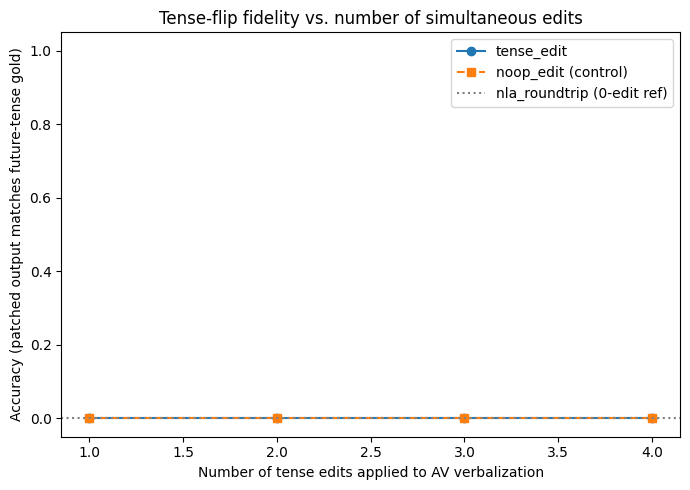

In [11]:
results = run_sweep(verbose=True)
plot_sweep(results)

## Cleanup

Close the AV client's HTTP session and stop SGLang only if this notebook launched it. An AV server that was already running before the notebook is left untouched.


In [12]:
if "client" in globals() and hasattr(client, "_http"):
    client._http.close()
    print("Closed NLA client HTTP session")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

if "sglang_proc" in globals() and sglang_proc is not None:
    sglang_proc.terminate()
    sglang_proc.wait(timeout=30)
    print("Stopped SGLang launched by this notebook")
else:
    print("No SGLang subprocess launched by this notebook")

# Optional final memory check:
# !nvidia-smi

Closed NLA client HTTP session
Stopped SGLang launched by this notebook
